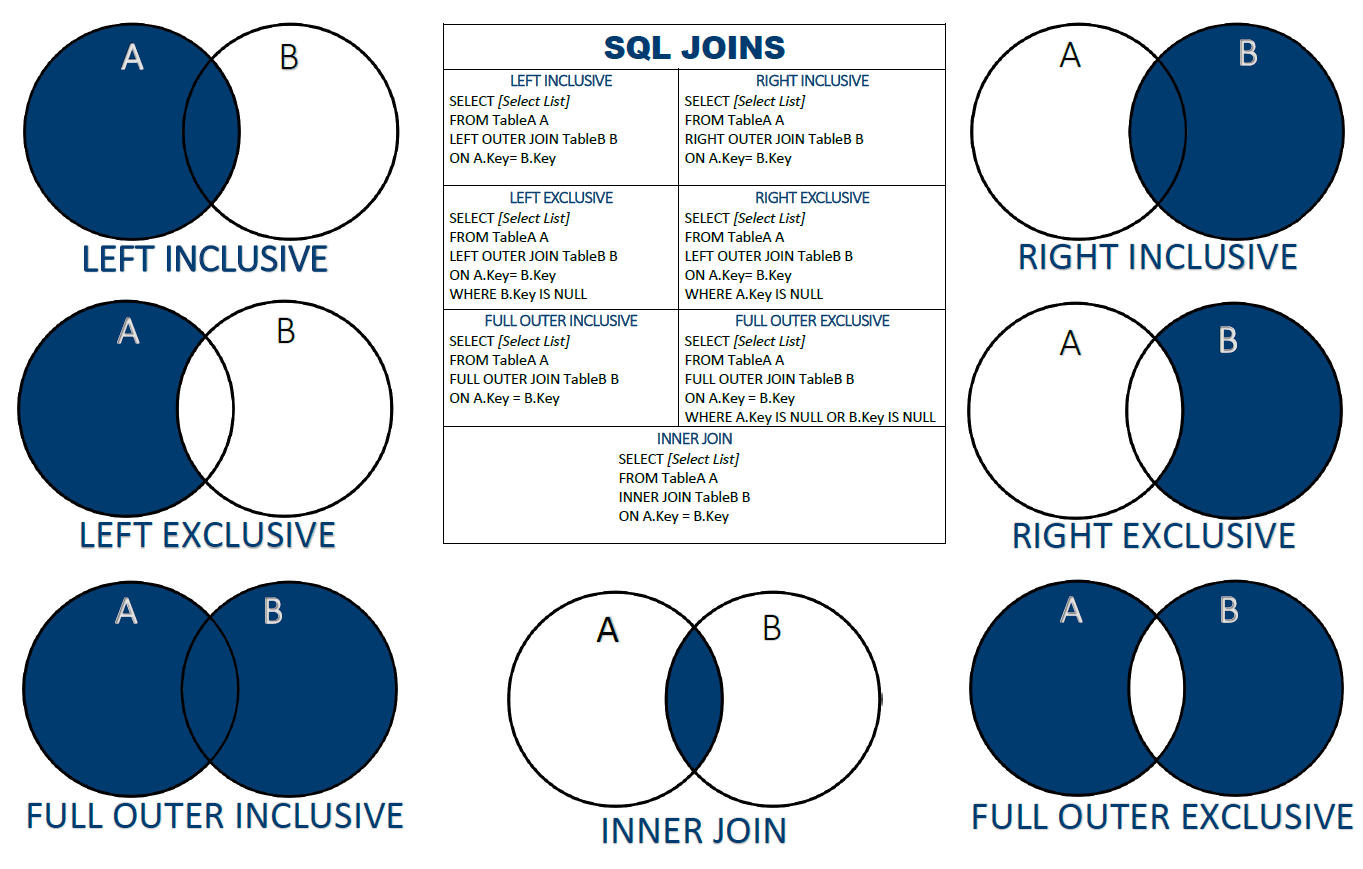

#### 1. Importar Bibliotecas

In [1]:
import sqlite3
import pandas as pd

#### 2. Criar conexão com banco de dados em memória

In [2]:
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

#### 3. Criar tabelas

In [3]:
# Tabela 1: Funcionarios
cursor.execute("""
CREATE TABLE Funcionarios (
id INTEGER PRIMARY KEY,
nome TEXT,
dep_id INTEGER
);
""")

# Tabela 2: Departamentos
cursor.execute("""
CREATE TABLE Departamentos (
id INTEGER PRIMARY KEY,
departamento TEXT
);
""")

#### 4. Inserir dados nas tabelas

In [4]:
# Inserir dados em Funcionarios
cursor.executemany("INSERT INTO Funcionarios VALUES (?, ?, ?)", [
(1, 'Ana', 10),
(2, 'Bruno', 20),
(3, 'Carla', None),
(4, 'Daniel', 30)
])

# Inserir dados em Departamentos
cursor.executemany("INSERT INTO Departamentos VALUES (?, ?)", [
(10, 'RH'),
(20, 'TI'),
(40, 'Marketing')
])

conn.commit()

#### 5. Visualizar tabelas

In [5]:
cursor.execute("SELECT * FROM funcionarios;")
pd.DataFrame(cursor.fetchall(), columns = ['id','nome','dep_id'])

,id,nome,dep_id
0,1,Ana,10.0
1,2,Bruno,20.0
2,3,Carla,NaN
3,4,Daniel,30.0


In [6]:
cursor.execute("SELECT * FROM departamentos;")
pd.DataFrame(cursor.fetchall(), columns = ['id','departamento'])

,id,departamento
0,10,RH
1,20,TI
2,40,Marketing


### INNER JOIN:

`INNER JOIN` é um formato comum de join, que retorna dados apenas quando as duas tabelas tem chaves correspondentes na cláusula ON do join.

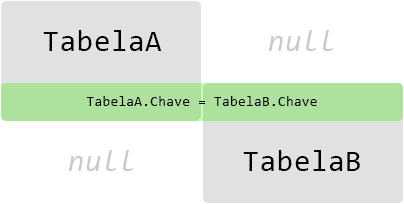

In [ ]:
cursor.execute('''
SELECT f.nome, d.departamento
FROM Funcionarios f
INNER JOIN Departamentos d
ON f.dep_id = d.id;
''')
inner_join_result = cursor.fetchall()
pd.DataFrame(inner_join_result, columns=["nome", "departamento"])

,nome,departamento
0,Ana,RH
1,Bruno,TI


### LEFT JOIN

`LEFT OUTER JOIN` ou simplesmente `LEFT JOIN` é um dos formatos mais usados de join, que retorna a Tabela A inteira e apenas os registros que coincidirem com a igualdade do join na Tabela B (ou campos nulos para os campos sem correspondência).

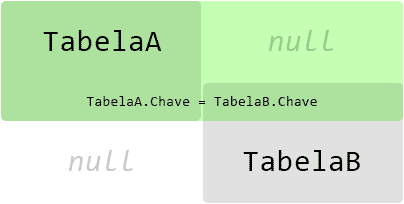

In [ ]:
cursor.execute('''
SELECT f.nome, d.departamento
FROM Funcionarios f
LEFT JOIN Departamentos d
ON f.dep_id = d.id;
''')
left_join_result = cursor.fetchall()
pd.DataFrame(left_join_result, columns=["nome", "departamento"])
# funcionarios sem departamento terão o valor None na coluna departamento (no caso, missing value para carla e daniel)

,nome,departamento
0,Ana,RH
1,Bruno,TI
2,Carla,NaN
3,Daniel,NaN


### RIGHT JOIN

`RIGHT OUTER JOIN` ou simplesmente `RIGHT JOIN` segue o mesmo raciocínio do LEFT JOIN, mas se aplicando à tabela B em vez da A:

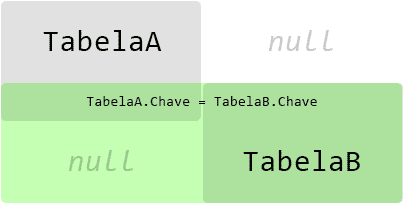

In [12]:
cursor.execute('''
SELECT f.nome, d.departamento
FROM Funcionarios f
RIGHT JOIN Departamentos d
ON f.dep_id = d.id;
''')
right_join_result = cursor.fetchall()
pd.DataFrame(right_join_result, columns=["nome", "departamento"])

,nome,departamento
0,Ana,RH
1,Bruno,TI
2,NaN,Marketing


In [14]:
cursor.execute("""
SELECT Departamentos d
LEFT JOIN Funcionarios f
ON f.dep_id = d.id;
""")
result_novo = cursor.fetchall()
pd.DataFrame(result_novo, columns= ["nome","departamento"])

OperationalError: near "LEFT": syntax error

### FULL JOIN 

Conhecida como `OUTER JOIN` ou simplesmente `FULL JOIN`, este retorna todos os registros de ambas as tabelas.

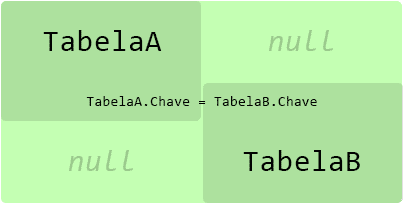

Obs: SQLite não suporta FULL JOIN diretamente. Então simulamos com UNION de LEFT JOIN e RIGHT JOIN.

In [10]:
cursor.execute('''
SELECT f.nome, d.departamento
FROM Funcionarios f
LEFT JOIN Departamentos d ON f.dep_id = d.id
UNION
SELECT f.nome, d.departamento
FROM Departamentos d
LEFT JOIN Funcionarios f ON f.dep_id = d.id;
''')
full_join_result = cursor.fetchall()
pd.DataFrame(full_join_result, columns=["nome", "departamento"])

,nome,departamento
0,NaN,Marketing
1,Ana,RH
2,Bruno,TI
3,Carla,NaN
4,Daniel,NaN


In [ ]:
cursor.execute('''
SELECT f.nome, d.departamento
FROM Funcionarios f
FULL OUTER JOIN Departamentos d
    ON f.dep_id = d.id;
''')

full_join_result = cursor.fetchall()
pd.DataFrame(full_join_result, columns=["nome", "departamento"])

,nome,departamento
0,Ana,RH
1,Bruno,TI
2,Carla,NaN
3,Daniel,NaN
4,NaN,Marketing


### CROSS JOIN: retorna o produto cartesiano entre as duas tabelas.

Basicamente é o produto cartesiano entre as duas tabelas. Para cada linha de Tabela A, são retornadas todas as linhas de Tabela B.

É mais fácil entender o CROSS JOIN como um "Join sem cláusula ON", ou seja, todas as combinações de linhas de A e B são devolvidas. Inclusive, se você fizer um CROSS JOIN com cláusula ON, ele "vira" um mero INNER JOIN.

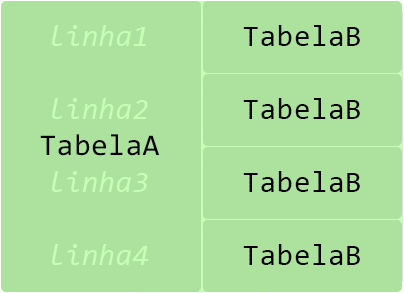

In [16]:
cursor.execute('''
SELECT f.nome, d.departamento
FROM Funcionarios f
CROSS JOIN Departamentos d;
''')
cross_join_result = cursor.fetchall()
pd.DataFrame(cross_join_result, columns=["nome", "departamento"])

,nome,departamento
0,Ana,RH
1,Ana,TI
2,Ana,Marketing
3,Bruno,RH
4,Bruno,TI
5,Bruno,Marketing
6,Carla,RH
7,Carla,TI
8,Carla,Marketing
9,Daniel,RH
